# Statistical Analysis of Burnout vs Retention





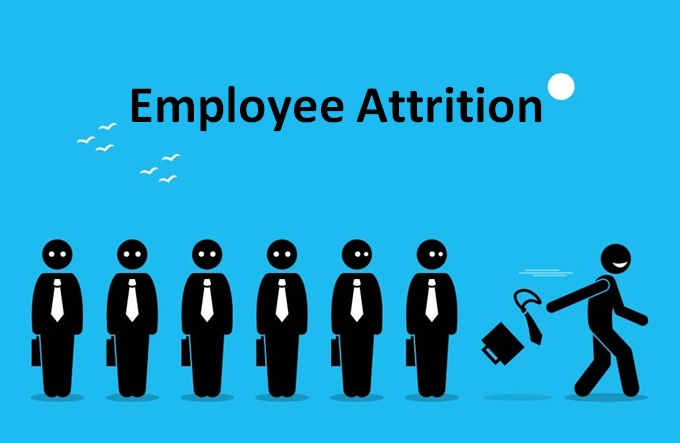

This visual represents employee attrition, where employees leave the organization over time.

## Business Understanding

***Employee attrition*** is a major challenge in professional service organizations, as it leads to increased recruitment costs, loss of experienced talent, and reduced overall productivity. One potential driver of attrition is employee burnout, often caused by excessive workload and overtime.

 - **So Understanding whether burnout contributes to employees leaving the company is critical for improving retention strategies.**

### Business Problem
The organization wants to identify whether factors related to employee workload—particularly overtime—are influencing attrition.

### Objective
The objective of this analysis is to:
- Examine the relationship between overtime (as a proxy for burnout) and employee attrition
- Identify key patterns in employee data that may explain why employees leave
- Provide data-driven insights to support better workforce management decisions

### Key Questions
- Are employees who work overtime more likely to leave?
- Does income level influence employee retention?
- Is there a relationship between work-life balance and employee tenure?

## Importing python libraries for my analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import chi2_contingency

#### Load Dataset that we have downloaded from kaggle

In [2]:
from google.colab import files
uploaded = files.upload()

Saving WA_Fn-UseC_-HR-Employee-Attrition.csv to WA_Fn-UseC_-HR-Employee-Attrition (2).csv


In [3]:
ibm =pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')
pd.set_option('display.max_columns', None)
ibm.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2


Let us understand our data before diving into statistical analysis

In [4]:
ibm.shape

(1470, 35)

In [5]:
ibm.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

**Observation:**

 our data set has 1470 entries and 35 columns .

 No column has missing value .


### Descriptive statistics on our key variables

In [6]:
ibm[['MonthlyIncome','TotalWorkingYears']].describe()

,MonthlyIncome,TotalWorkingYears
count,1470.000000,1470.000000
mean,6502.931293,11.279592
std,4707.956783,7.780782
min,1009.000000,0.000000
25%,2911.000000,6.000000
50%,4919.000000,10.000000
75%,8379.000000,15.000000
max,19999.000000,40.000000


In [7]:
ibm[['OverTime']].value_counts()


,count
OverTime,
No,1054
Yes,416


## Correlation Analysis

**To understand how the main variables are related, I used a heatmap of selected features instead of all columns to keep it clear.**

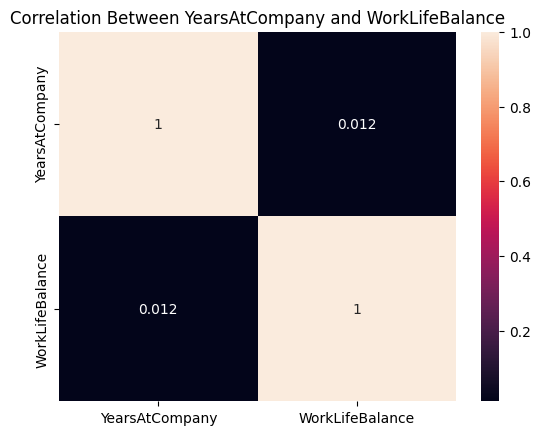

In [8]:
corr_Year_Work = ibm[['YearsAtCompany','WorkLifeBalance']].corr()
sns.heatmap(corr_Year_Work, annot=True)
plt.title("Correlation Between YearsAtCompany and WorkLifeBalance")
plt.show()

- YearsAtCompany and WorkLifeBalance have a correlation of 0.012

This heatmap shows how strongly variables are connected. Values closer to 1 or -1 mean stronger relationships, while values near 0 mean weak relationships.

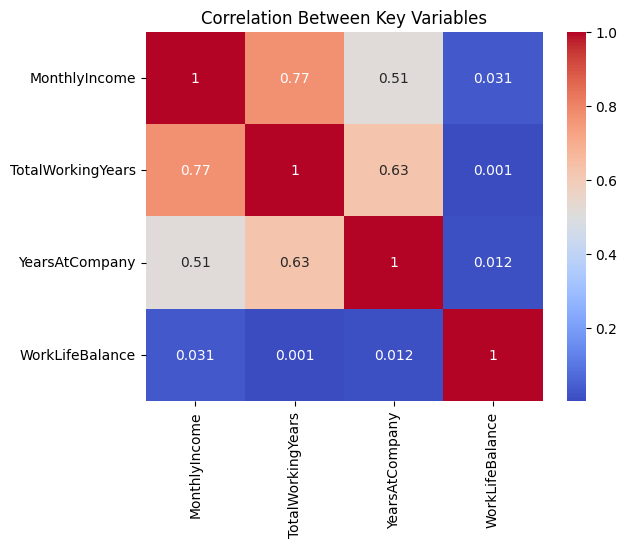

In [9]:
cols = ['MonthlyIncome', 'TotalWorkingYears',
        'YearsAtCompany', 'WorkLifeBalance']

sns.heatmap(ibm[cols].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Between Key Variables")
plt.show()







### Key Observations
- Years at company and total working years are positively related, which makes sense
- Work-life balance has a weak relationship with tenure
- Monthly income increases with experience

Overall, most relationships are not very strong, which suggests that attrition is influenced by multiple factors.

## **Hypothesis Testing: Overtime vs Attrition**

To statistically evaluate whether overtime affects employee attrition, I performed a Chi-Square test of independence.

### Hypotheses
- Null Hypothesis : Overtime and attrition are independent
- Alternative Hypothesis: Overtime and attrition are related



In [10]:
contingency = pd.crosstab(ibm['OverTime'], ibm['Attrition'])

chi2, p, dof, expected = chi2_contingency(contingency)

print("Chi-square:", chi2)
print("p-value:", p)

Chi-square: 87.56429365828768
p-value: 8.15842372153832e-21


### **Result**
The test produced a p-value less than 0.05.
Since the p-value is below the significance level, we reject the null hypothesis.

This indicates a statistically significant relationship between overtime and attrition, suggesting that employees working overtime are more likely to leave.

## **Data Visualization**

I used visualizations to better understand patterns in employee attrition and make the results easier to interpret.

### **1. Attrition vs Overtime**
This chart compares employees who work overtime with those who do not.


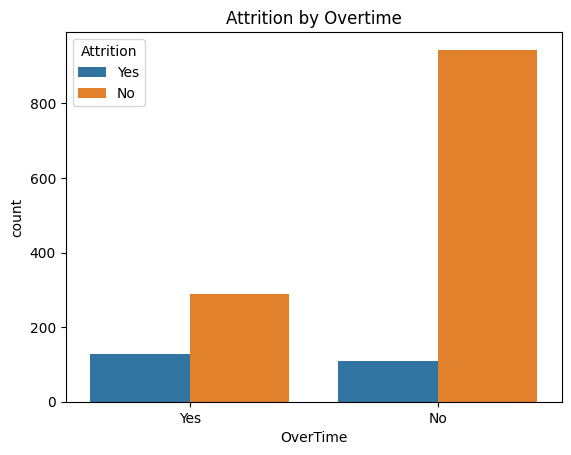

In [11]:
sns.countplot(x='OverTime', hue='Attrition', data=ibm)
plt.title("Attrition by Overtime")
plt.show()

Employees working overtime have a higher proportion of attrition. let us see the percentage ration by visualizing stacked bar chart.

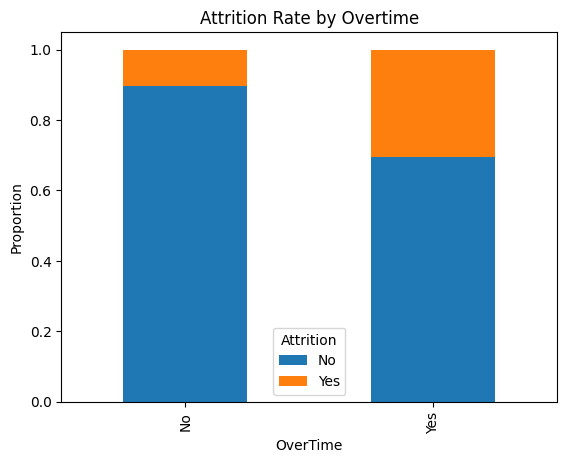

In [12]:
attrition_rate = pd.crosstab(ibm['OverTime'], ibm['Attrition'], normalize='index')

attrition_rate.plot(kind='bar', stacked=True)
plt.title("Attrition Rate by Overtime")
plt.ylabel("Proportion")
plt.show()


**Observation:**
Employees who work overtime seem more likely to leave the company. This suggests that higher workload may be linked to higher attrition.

---

### **2. Income vs Attrition**
This plot shows the distribution of monthly income for employees who stayed and those who left.



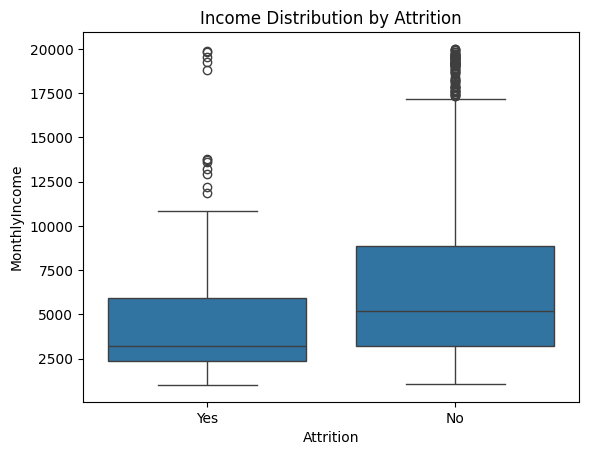

In [13]:
sns.boxplot(data=ibm, x='Attrition', y='MonthlyIncome')
plt.title("Income Distribution by Attrition")
plt.show()

**Observation:**
Employees who left generally have lower income compared to those who stayed. This indicates that salary may play a role in retention.

---

### 3. **Attrition by Work-Life Balance**



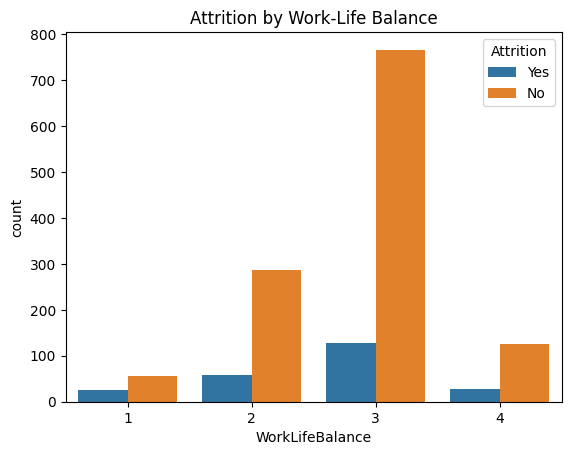

In [14]:
sns.countplot(data=ibm, x='WorkLifeBalance', hue='Attrition')
plt.title("Attrition by Work-Life Balance")
plt.show()

**Observation:**

Most employees report a work-life balance level of 3, and the majority of them stayed with the company.

However, employees with lower work-life balance (levels 1 and 2) show a relatively higher number of attrition cases compared to their group size.

Employees with better work-life balance (level 4) appear less likely to leave.

Overall, this suggests that poor work-life balance may contribute to higher attrition, although the relationship is not very strong.

### 4. **Years at Company vs Attrition**

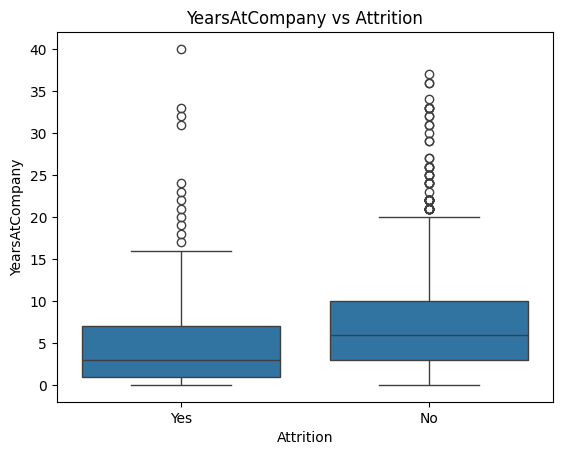

In [15]:
sns.boxplot(data=ibm, x='Attrition', y='YearsAtCompany')
plt.title("YearsAtCompany vs Attrition")
plt.show()

**Observation:**
Employees who left the company tend to have fewer years at the company, with a lower median compared to those who stayed.

In contrast, employees who stayed generally have longer yearatcompany and a wider range of years.

There are also some long-tenure employees who left, but they are fewer compared to those who stayed.

Overall, this suggests that employees are more likely to leave earlier in their careers rather than after staying for many years.

## Conclusion

In this analysis, I explored how different factors relate to employee attrition.

- The results show that employees who work overtime are more likely to leave the company, and this relationship is statistically significant. This suggests that heavy workload may contribute to employee burnout and turnover.

- I also found that employees with lower income and fewer years at the company tend to leave more often. This shows that both compensation and early experience in the company are important for retention.

- overall, attrition is influenced by multiple factors, but overtime appears to be one of the key drivers.

- These findings suggest that companies can improve retention by managing workload, supporting work-life balance, and paying attention to employees in the early stages of their careers.